# Analysis of Attention Weight Distributions and Spatial Patterns

This notebook focuses on analyzing the attention weight distributions and their spatial patterns in the context of a graph-based model. Specifically, it examines the attention weights generated by a hybrid model trained on the `BasicData` dataset. The goal is to identify patterns in the attention weights, such as multi-modal distributions, and explore their spatial implications.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import LineString, Point
import torch
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from scipy import stats

Total attention weight pairs: 12063872
Layers: ['Layer 0' 'Layer 1' 'Layer 2' 'Layer 3']
Heads: ['Head 0' 'Head 1']


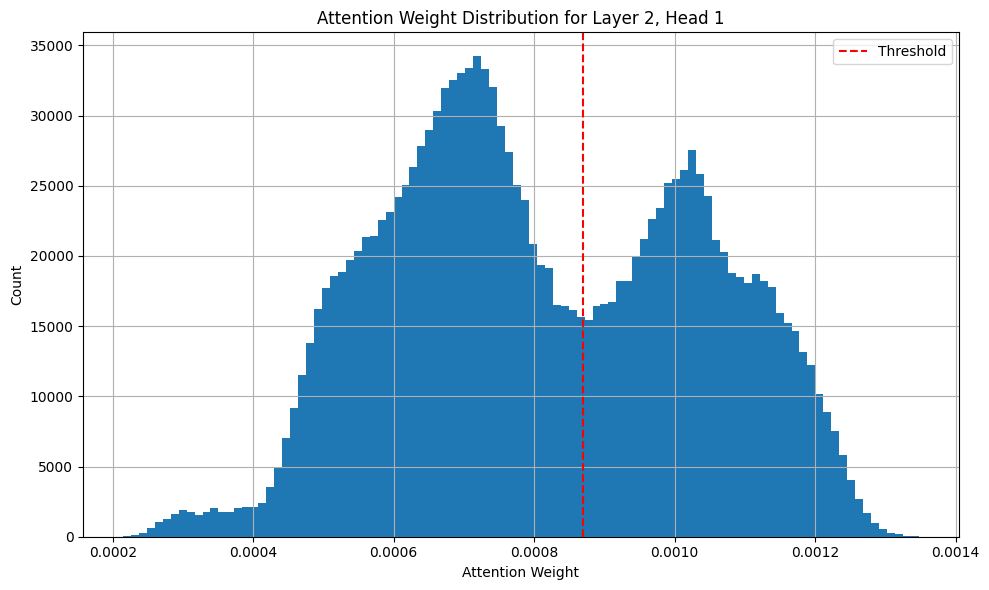

In [8]:

# Load the saved attention weights
attn_df = pd.read_csv('attention_weights_basic.csv', index_col=0)

# Load the H3 nodes for spatial analysis
h3_nodes = gpd.read_file('h3_nodes.geojson')
#h3_nodes.index = h3_nodes['h3_09'] 
#h3_nodes.drop(columns=['h3_09'], inplace=True)

# Load the node mapping for converting between indices and H3 IDs
node_mapping = {node_id: idx for idx, node_id in enumerate(h3_nodes.index)}
reverse_mapping = {idx: h3_id for h3_id, idx in node_mapping.items()}

# Display basic info about the dataset
print(f"Total attention weight pairs: {len(attn_df)}")
print(f"Layers: {attn_df['layer'].unique()}")
print(f"Heads: {attn_df['head'].unique()}")

# Initial visualization of distribution for a specific layer and head
layer = 'Layer 2'
head = 'Head 1'

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
subset = attn_df[(attn_df['layer'] == layer) & (attn_df['head'] == head)]
subset.hist(column='weight', bins=100, ax=ax)
ax.set_title(f'Attention Weight Distribution for {layer}, {head}')
ax.set_xlabel('Attention Weight')
ax.set_ylabel('Count')

# Identify peaks in the distribution
# You could use GMM to identify the components
threshold = 0.00087  # Based on your previous analysis
ax.axvline(threshold, color='red', linestyle='--', label='Threshold')
ax.legend()
plt.tight_layout()
plt.show()

<Axes: >

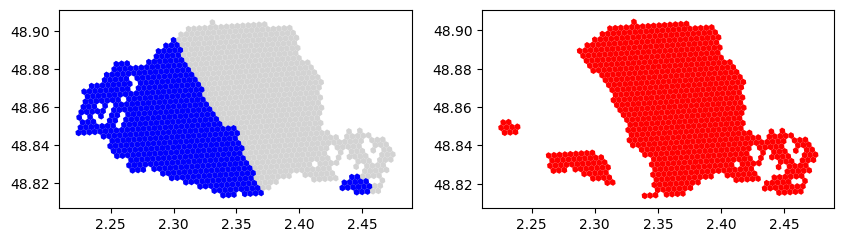

In [3]:
#select weights, target nodes, and source nodes above the threshold
subset_above_threshold = subset[subset['weight'] > threshold]
subset_above_threshold.head()
subset_below_threshold = subset[subset['weight'] <= threshold]

f, axs = plt.subplots(1, 2, figsize=(10, 6))
h3_nodes.plot(ax = axs[0], color='lightgrey', markersize=1)
h3_nodes[h3_nodes.index.isin(subset_above_threshold['target'])].plot(ax = axs[0], color='blue', markersize=5)

h3_nodes[h3_nodes.index.isin(subset_below_threshold['target'])].plot(ax = axs[1], color='red', markersize=5)

Target Nodes (More Interesting in Most Cases)
The target nodes are those being attended to:
- They represent the information hubs in the network
- They show which locations are considered influential by the model


In [32]:
# compute average distance between nodes above and below the threshold
def compute_average_distance(subset, h3_nodes):
    source_nodes = h3_nodes[h3_nodes.index.isin(subset['source'])][['geometry']]
    target_nodes = h3_nodes[h3_nodes.index.isin(subset['target'])][['geometry']]
    distances = []
    for source in source_nodes.itertuples():
        for target in target_nodes.itertuples():
            #if source.Index != target.Index:  # Avoid self-distance
                distance = source.geometry.distance(target.geometry)
                distances.append(distance)
    if distances:
        avg_distance = np.mean(distances)
    else:
        avg_distance = 0
        print("No distances computed, check the subsets.")

    
    return avg_distance

avg_distance_above = compute_average_distance(subset_above_threshold, h3_nodes)
avg_distance_below = compute_average_distance(subset_below_threshold, h3_nodes)
print(f"Average distance for nodes above threshold: {avg_distance_above}")
print(f"Average distance for nodes below threshold: {avg_distance_below}")

Average distance for nodes above threshold: 0.07077349204346528
Average distance for nodes below threshold: 0.06763617549022027


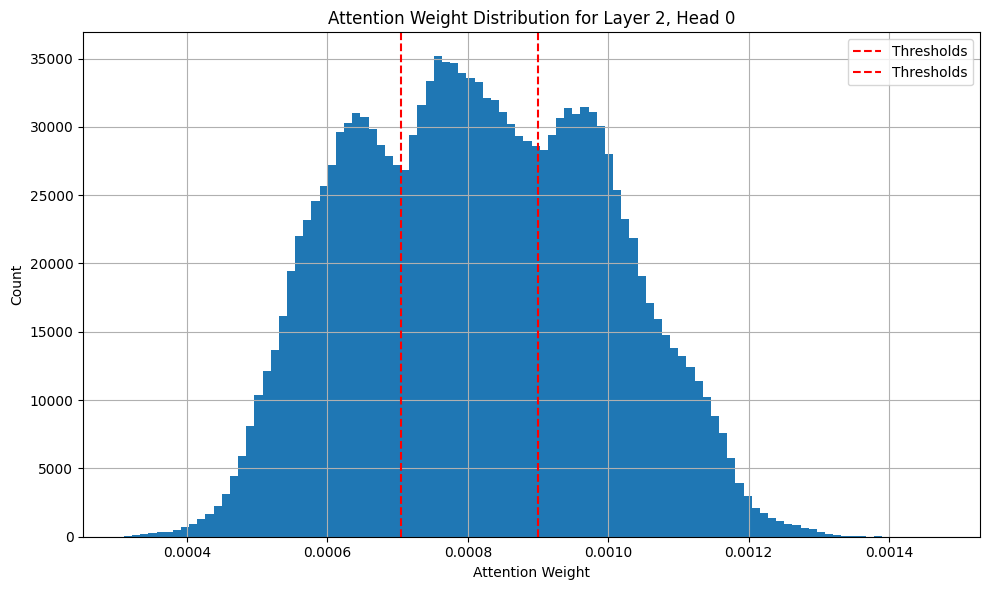

In [4]:
layer = 'Layer 2'
head = 'Head 0'

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
subset = attn_df[(attn_df['layer'] == layer) & (attn_df['head'] == head)]
subset.hist(column='weight', bins=100, ax=ax)
ax.set_title(f'Attention Weight Distribution for {layer}, {head}')
ax.set_xlabel('Attention Weight')
ax.set_ylabel('Count')

thresholds = [0.000705, 0.0009]  
ax.axvline(thresholds[0], color='red', linestyle='--', label='Thresholds')
ax.axvline(thresholds[1], color='red', linestyle='--', label='Thresholds')
ax.legend()
plt.tight_layout()
plt.show()


<Axes: >

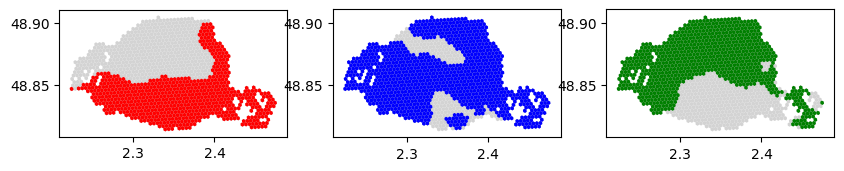

In [5]:
#select weights, target nodes, and source nodes above the threshold
subset_small= subset[subset['weight'] <= thresholds[0]]
subset_mid = subset[(subset['weight'] > thresholds[0]) & (subset['weight'] <= thresholds[1])]
subset_large = subset[subset['weight'] > thresholds[1]]

f, axs = plt.subplots(1, 3, figsize=(10, 6))
h3_nodes.plot(ax = axs[0], color='lightgrey', markersize=1)
h3_nodes[h3_nodes.index.isin(subset_small['target'])].plot(ax = axs[0], color='red', markersize=5)
h3_nodes.plot(ax = axs[1], color='lightgrey', markersize=1)
h3_nodes[h3_nodes.index.isin(subset_mid['target'])].plot(ax = axs[1], color='blue', markersize=5)
h3_nodes.plot(ax = axs[2], color='lightgrey', markersize=1)
h3_nodes[h3_nodes.index.isin(subset_large['target'])].plot(ax = axs[2], color='green', markersize=5)

In [59]:
avg_distance_small = compute_average_distance(subset_small, h3_nodes)
avg_distance_mid = compute_average_distance(subset_mid, h3_nodes)
avg_distance_large = compute_average_distance(subset_large, h3_nodes)
print(f"Average distance for nodes small: {avg_distance_small}")
print(f"Average distance for nodes mid: {avg_distance_mid}")
print(f"Average distance for nodes large: {avg_distance_large}")

Average distance for nodes small: 0.07219441537539406
Average distance for nodes mid: 0.071132870260403
Average distance for nodes large: 0.07141472256169139


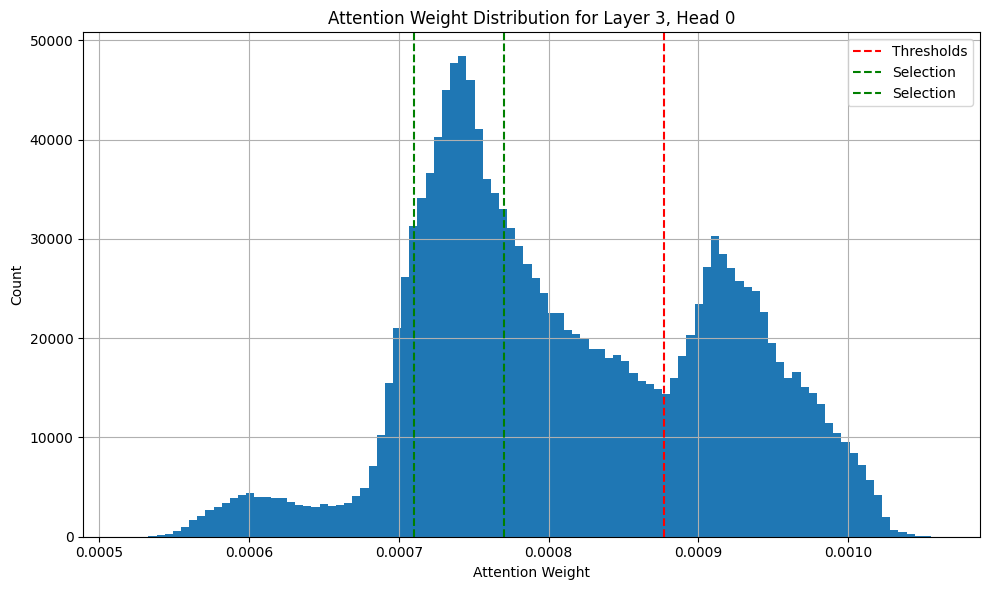

In [9]:
layer = 'Layer 3'
head = 'Head 0'

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
subset = attn_df[(attn_df['layer'] == layer) & (attn_df['head'] == head)]
subset.hist(column='weight', bins=100, ax=ax)
ax.set_title(f'Attention Weight Distribution for {layer}, {head}')
ax.set_xlabel('Attention Weight')
ax.set_ylabel('Count')

threshold = 0.000877 
selection = [0.00071, 0.00077]
ax.axvline(threshold, color='red', linestyle='--', label='Thresholds')
ax.axvline(selection[0], color='green', linestyle='--', label='Selection')
ax.axvline(selection[1], color='green', linestyle='--', label='Selection')
ax.legend()
plt.tight_layout()
plt.show()


<Axes: >

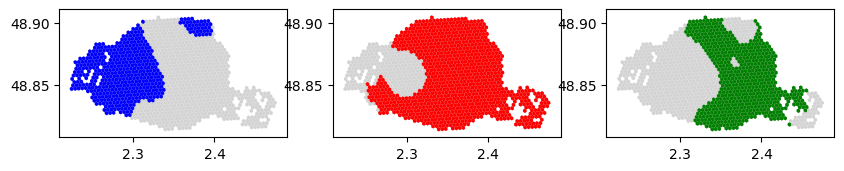

In [ ]:
subset_above_threshold = subset[subset['weight'] > threshold]
subset_below_threshold = subset[subset['weight'] <= threshold]
selection_subset = subset[(subset['weight'] > selection[0]) & (subset['weight'] <= selection[1])]
f, axs = plt.subplots(1, 3, figsize=(10, 6))
h3_nodes.plot(ax = axs[0], color='lightgrey', markersize=1)
h3_nodes[h3_nodes.index.isin(subset_above_threshold['target'])].plot(ax = axs[0], color='blue', markersize=5)
h3_nodes.plot(ax = axs[1], color='lightgrey', markersize=1)
h3_nodes[h3_nodes.index.isin(subset_below_threshold['target'])].plot(ax = axs[1], color='red', markersize=5)
h3_nodes.plot(ax = axs[2], color='lightgrey', markersize=1)
h3_nodes[h3_nodes.index.isin(selection_subset['target'])].plot(ax = axs[2], color='green', markersize=5)

In [68]:
avg_distance_below = compute_average_distance(subset_below_threshold, h3_nodes)
avg_distance_above = compute_average_distance(subset_above_threshold, h3_nodes)
print(f"Average distance for nodes above threshold: {avg_distance_above}")
print(f"Average distance for nodes below threshold: {avg_distance_below}")

Average distance for nodes above threshold: 0.07203765670325116
Average distance for nodes below threshold: 0.06718573088429731


given the red nodes in a layer (eg the ones associated to the longest and highest attention edges), in the next layer, what are the properties of the attention edges of those same nodes? Are still among the largest? Are shorter?

In [10]:
# select top k of the attention weights
def select_top_k_weights(subset, k=10):
    top_k = subset.nlargest(k, 'weight')
    return top_k

top_k_above = select_top_k_weights(attn_df[(attn_df['layer'] == 'Layer 0') & (attn_df['head'] == 'Head 0')], k=10)
print("Top K Attention Weights:")
print(top_k_above)

Top K Attention Weights:
          layer    head  source  target    weight
487639  Layer 0  Head 0     397     123  0.001845
490095  Layer 0  Head 0     399     123  0.001832
487640  Layer 0  Head 0     397     124  0.001831
482727  Layer 0  Head 0     393     123  0.001828
487642  Layer 0  Head 0     397     126  0.001827
487644  Layer 0  Head 0     397     128  0.001821
490096  Layer 0  Head 0     399     124  0.001818
487641  Layer 0  Head 0     397     125  0.001816
482728  Layer 0  Head 0     393     124  0.001815
490098  Layer 0  Head 0     399     126  0.001815


<Axes: >

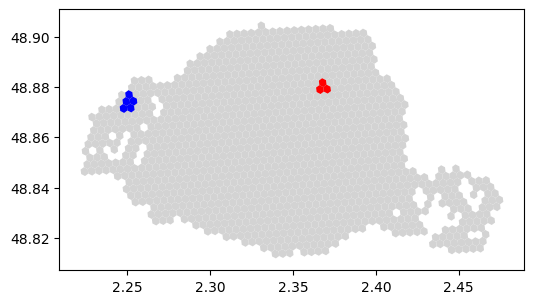

In [4]:
# Visualize the top k attention weights
f, ax = plt.subplots(1, 1, figsize=(6, 6))
h3_nodes.plot(ax=ax, color='lightgrey', markersize=1)
h3_nodes[h3_nodes.index.isin(top_k_above['target'])].plot(ax=ax, color='blue', markersize=5)
h3_nodes[h3_nodes.index.isin(top_k_above['source'])].plot(ax=ax, color='red', markersize=5)


Analysis of high-attention nodes across layers ('Layer 2', 'Layer 3') heads ['Head 0', 'Head 1']:
------------------------------
Relative importance in base layer: 1.47x the average
Relative importance in next layer: 1.12x the average
Average distance in base layer: 0.051114
Average distance in next layer: 0.041441


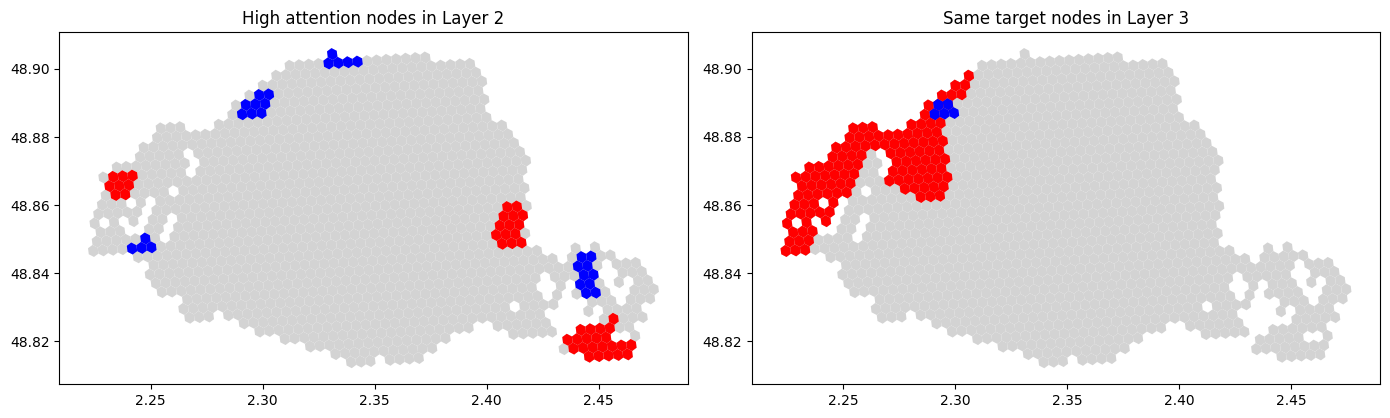

In [14]:
def track_attention_across_layers(attn_df, h3_nodes, base_layer, next_layer, heads=['Head 0', 'Head 1'], top_k=10):
    """
    Track how high-attention nodes in one layer behave in the next layer,
    considering multiple attention heads.
    
    Parameters:
    -----------
    attn_df: DataFrame with attention weights
    h3_nodes: GeoDataFrame with node geometries
    base_layer: Initial layer to find high attention nodes (e.g., 'Layer 0')
    next_layer: Subsequent layer to analyze (e.g., 'Layer 1')
    heads: List of attention heads to analyze
    top_k: Number of top attention weights to consider
    
    Returns:
    --------
    Dictionary with analysis results
    """
    # Get weights for specified heads in base layer
    base_subsets = []
    for head in heads:
        subset = attn_df[(attn_df['layer'] == base_layer) & (attn_df['head'] == head)]
        base_subsets.append(subset)
    
    # Combine weights from all heads
    base_combined = pd.concat(base_subsets)
    
    # For each source-target pair, keep only the maximum weight across heads
    base_combined = base_combined.groupby(['source', 'target'])['weight'].max().reset_index()

    overall_avg = base_combined['weight'].mean()
    
    # Get top k from the combined weights
    top_k_base = select_top_k_weights(base_combined, k=top_k)
    
    # Extract source and target nodes that had high attention
    high_attn_sources = set(top_k_base['source'])
    high_attn_targets = set(top_k_base['target'])
    high_attn_nodes = high_attn_sources.union(high_attn_targets)


    base_layer_edges = base_combined[base_combined['target'].isin(high_attn_targets)]
    # select only top_k of these edges
    ordered_base_edges = base_layer_edges.sort_values(by='weight', ascending=False)
    base_layer_edges = ordered_base_edges.head(top_k)


    # Compute average weight for these edges
    avg_weight_base = base_layer_edges['weight'].mean()
    
    # Find these same nodes in the next layer, across all specified heads
    next_subsets = []
    for head in heads:
        subset = attn_df[(attn_df['layer'] == next_layer) & (attn_df['head'] == head)]
        next_subsets.append(subset)
    
    next_combined = pd.concat(next_subsets)
    next_combined = next_combined.groupby(['source', 'target'])['weight'].max().reset_index()
    
    # Filter for edges where target was a high-attention node in previous layer
    next_layer_edges = next_combined[(next_combined['target'].isin(high_attn_targets))]
    #select only top_k of these edges
    ordered_next_edges = next_layer_edges.sort_values(by='weight', ascending=False)
    next_layer_edges = ordered_next_edges.head(top_k)
    
    # Compute statistics
    avg_weight_next = next_layer_edges['weight'].mean()
    
    # Compare with overall average in next layer
    overall_avg_next = next_combined['weight'].mean()
    
    # Compute distances for base layer high attention edges
    base_distances = []
    for _, row in top_k_base.iterrows():
        source_h3 = reverse_mapping[int(row['source'])]
        target_h3 = reverse_mapping[int(row['target'])]
        source_geom = h3_nodes.loc[source_h3, 'geometry']
        target_geom = h3_nodes.loc[target_h3, 'geometry']
        distance = source_geom.distance(target_geom)
        base_distances.append(distance)
    
    # Compute distances for next layer edges of those same nodes
    next_distances = []
    for _, row in next_layer_edges.iterrows():
        source_h3 = reverse_mapping[int(row['source'])]
        target_h3 = reverse_mapping[int(row['target'])]
        source_geom = h3_nodes.loc[source_h3, 'geometry']
        target_geom = h3_nodes.loc[target_h3, 'geometry']
        distance = source_geom.distance(target_geom)
        next_distances.append(distance)
    
    # Results
    results = {
        'base_layer': base_layer,
        'next_layer': next_layer,
        'heads': heads,
        'high_attn_nodes_count': len(high_attn_nodes),
        'edges_in_next_layer': len(next_layer_edges),
        'avg_weight_base': avg_weight_base,
        'overall_avg_base': overall_avg,
        'relative_importance_base':avg_weight_base / overall_avg if overall_avg > 0 else 0,
        'avg_weight_next': avg_weight_next,
        'overall_avg_next': overall_avg_next,
        'relative_importance_next': avg_weight_next / overall_avg_next if overall_avg_next > 0 else 0,
        'avg_distance_base': np.mean(base_distances) if base_distances else 0,
        'avg_distance_next': np.mean(next_distances) if next_distances else 0,
        'top_k_base': top_k_base,
        'next_layer_edges': next_layer_edges
    }
    
    return results, high_attn_sources, high_attn_targets

# Example usage
results, high_attn_sources, high_attn_targets = track_attention_across_layers(attn_df, h3_nodes, 'Layer 2', 'Layer 3', heads=['Head 0','Head 1'], top_k=200)

# Print summary
print(f"Analysis of high-attention nodes across layers {results['base_layer'], results['next_layer']} heads {results['heads']}:")
print("------------------------------")
print(f"Relative importance in base layer: {results['relative_importance_base']:.2f}x the average")
print(f"Relative importance in next layer: {results['relative_importance_next']:.2f}x the average")
print(f"Average distance in base layer: {results['avg_distance_base']:.6f}")
print(f"Average distance in next layer: {results['avg_distance_next']:.6f}")

# Visualize the comparison
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Base layer visualization
h3_nodes.plot(ax=axs[0], color='lightgrey', markersize=1)
h3_nodes[h3_nodes.index.isin(high_attn_sources)].plot(ax=axs[0], color='red', markersize=5)
h3_nodes[h3_nodes.index.isin(high_attn_targets)].plot(ax=axs[0], color='blue', markersize=5)
axs[0].set_title(f"High attention nodes in {results['base_layer']}")


# Next layer visualization (how these same nodes behave)
h3_nodes.plot(ax=axs[1], color='lightgrey', markersize=1)
next_sources = results['next_layer_edges']['source'].unique()
next_targets = results['next_layer_edges']['target'].unique()
h3_nodes[h3_nodes.index.isin(next_sources)].plot(ax=axs[1], color='red', markersize=5)
h3_nodes[h3_nodes.index.isin(next_targets)].plot(ax=axs[1], color='blue', markersize=5)
axs[1].set_title(f"Same target nodes in {results['next_layer']}")

plt.tight_layout()
plt.show()

GPS LIKE MODEL

Total attention weight pairs: 12063872
Layers: ['Layer 0' 'Layer 1' 'Layer 2' 'Layer 3']
Heads: ['Head 0' 'Head 1']


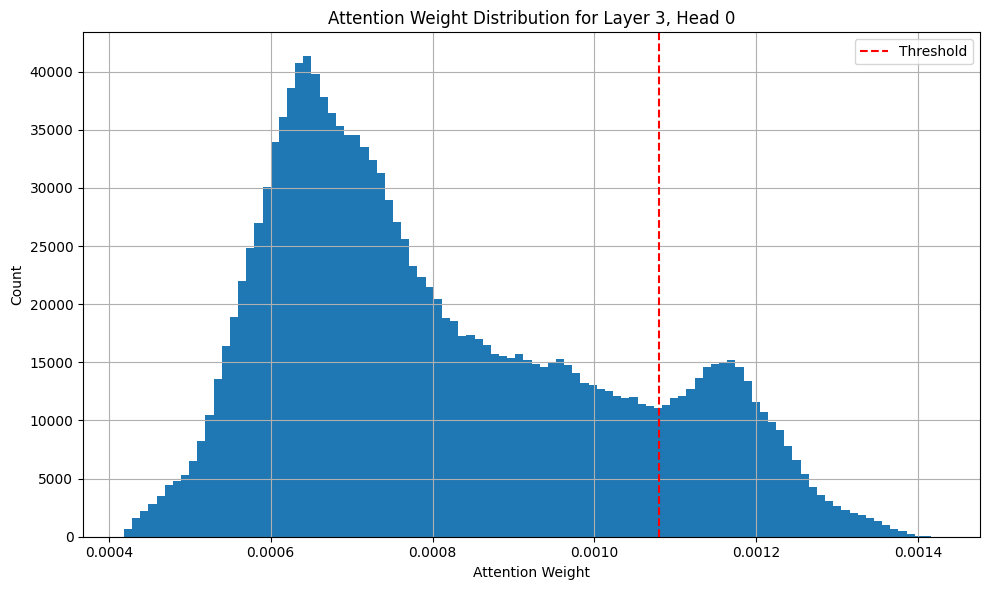

In [6]:

# Load the saved attention weights
attn_df = pd.read_csv('attention_weights_basic_gpslike.csv', index_col=0)

# Load the H3 nodes for spatial analysis
h3_nodes = gpd.read_file('h3_nodes.geojson')
#h3_nodes.index = h3_nodes['h3_09'] 
#h3_nodes.drop(columns=['h3_09'], inplace=True)

# Load the node mapping for converting between indices and H3 IDs
node_mapping = {node_id: idx for idx, node_id in enumerate(h3_nodes.index)}
reverse_mapping = {idx: h3_id for h3_id, idx in node_mapping.items()}

# Display basic info about the dataset
print(f"Total attention weight pairs: {len(attn_df)}")
print(f"Layers: {attn_df['layer'].unique()}")
print(f"Heads: {attn_df['head'].unique()}")

# Initial visualization of distribution for a specific layer and head
layer = 'Layer 3'
head = 'Head 0'

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
subset = attn_df[(attn_df['layer'] == layer) & (attn_df['head'] == head)]
subset.hist(column='weight', bins=100, ax=ax)
ax.set_title(f'Attention Weight Distribution for {layer}, {head}')
ax.set_xlabel('Attention Weight')
ax.set_ylabel('Count')

# Identify peaks in the distribution
# You could use GMM to identify the components
threshold = 0.00108  # Based on your previous analysis
ax.axvline(threshold, color='red', linestyle='--', label='Threshold')
ax.legend()
plt.tight_layout()
plt.show()

<Axes: >

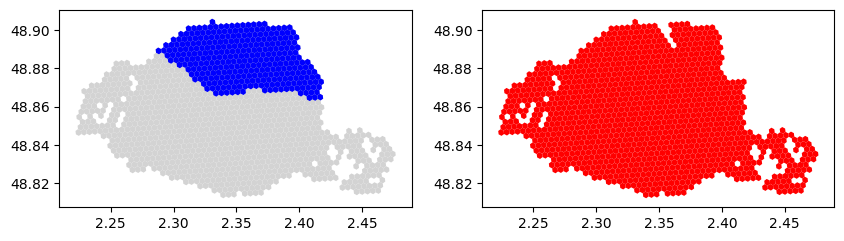

In [7]:
#select weights, target nodes, and source nodes above the threshold
subset_above_threshold = subset[subset['weight'] > threshold]
subset_above_threshold.head()
subset_below_threshold = subset[subset['weight'] <= threshold]

f, axs = plt.subplots(1, 2, figsize=(10, 6))
h3_nodes.plot(ax = axs[0], color='lightgrey', markersize=1)
h3_nodes[h3_nodes.index.isin(subset_above_threshold['target'])].plot(ax = axs[0], color='blue', markersize=5)

h3_nodes[h3_nodes.index.isin(subset_below_threshold['target'])].plot(ax = axs[1], color='red', markersize=5)